# Notebook 03 — RFM Segmentation & Loyalty ROI
**Project:** E-Commerce Revenue Leakage  
**Input:** `../data/processed/events_clean.parquet`  
**Output:** `../data/processed/loyalty_offers.csv`, `charts/chart_05–08.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('charts', exist_ok=True)

TEAL   = '#1D9E75'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
BLUE   = '#4A90D9'
GRAY   = '#AAAAAA'

SEGMENT_COLORS = {
    'Champion':       '#1D9E75',
    'Loyal Customer': '#4A90D9',
    'New Customer':   '#7BC8A4',
    'Needs Attention':'#EF9F27',
    'At Risk':        '#D85A30',
    'Can\'t Lose Them': '#C0392B',
    'Lost':           '#888888',
}

df = pd.read_parquet('../data/processed/events_clean.parquet')
df['event_date'] = pd.to_datetime(df['event_date'])
print(f"Loaded: {len(df):,} rows")

Loaded: 884,474 rows


## 3.1 Build Purchase History

In [2]:
purchases = df[df['event_type'] == 'purchase'].copy()
print(f"Purchase events: {len(purchases):,}")

max_date = purchases['event_date'].max()
print(f"Reference date (max_date): {max_date}")

purchase_history = purchases.groupby('user_id').agg(
    last_purchase_date=('event_date', 'max'),
    frequency=('user_session', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

purchase_history['recency_days'] = (max_date - purchase_history['last_purchase_date']).dt.days

print(f"\nUnique buyers: {len(purchase_history):,}")
purchase_history.describe()

Purchase events: 37,343
Reference date (max_date): 2021-02-28 00:00:00

Unique buyers: 21,304


,user_id,last_purchase_date,frequency,monetary,recency_days
count,2.130400e+04,21304,21304.000000,21304.000000,21304.000000
mean,1.515916e+18,2020-12-16 10:48:17.033420800,1.142884,238.339775,73.549803
min,1.515916e+18,2020-09-24 00:00:00,1.000000,0.370000,0.000000
25%,1.515916e+18,2020-11-08 00:00:00,1.000000,32.220000,34.000000
50%,1.515916e+18,2020-12-19 00:00:00,1.000000,90.630000,71.000000
75%,1.515916e+18,2021-01-25 00:00:00,1.000000,287.457500,112.000000
max,1.515916e+18,2021-02-28 00:00:00,10.000000,12080.830000,157.000000
std,3.459948e+07,NaN,0.445450,414.644025,45.094850


## 3.2 Compute RFM Scores & Segment Labels

In [3]:
ph = purchase_history.copy()

# Lower recency_days = more recent = better score → ascending order, higher rank = better
ph['r_score'] = pd.qcut(ph['recency_days'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
ph['f_score'] = pd.qcut(ph['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
ph['m_score'] = pd.qcut(ph['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

def rfm_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

ph['rfm_segment'] = ph.apply(rfm_segment, axis=1)

print("Segment distribution:")
print(ph['rfm_segment'].value_counts())

Segment distribution:
rfm_segment
Loyal Customer     8226
Lost               7571
Champion           3731
Needs Attention     843
Can't Lose Them     472
New Customer        269
At Risk             192
Name: count, dtype: int64


In [4]:
# Segment summary table
total_revenue = ph['monetary'].sum()
seg_summary = ph.groupby('rfm_segment').agg(
    user_count=('user_id', 'count'),
    avg_recency_days=('recency_days', 'mean'),
    avg_orders=('frequency', 'mean'),
    avg_revenue=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).reset_index()

seg_summary['pct_of_users']   = (100 * seg_summary['user_count'] / seg_summary['user_count'].sum()).round(1)
seg_summary['pct_of_revenue'] = (100 * seg_summary['total_revenue'] / total_revenue).round(1)
seg_summary = seg_summary.sort_values('avg_revenue', ascending=False)

print(seg_summary[['rfm_segment','user_count','pct_of_users','avg_recency_days',
                    'avg_orders','avg_revenue','total_revenue','pct_of_revenue']].to_string(index=False))

    rfm_segment  user_count  pct_of_users  avg_recency_days  avg_orders  avg_revenue  total_revenue  pct_of_revenue
Can't Lose Them         472           2.2        116.677966    2.243644   683.824364      322765.10             6.4
       Champion        3731          17.5         24.639239    1.297239   598.835001     2234253.39            44.0
   New Customer         269           1.3         29.204461    1.000000   204.479145       55004.89             1.1
 Loyal Customer        8226          38.6         47.315342    1.118162   158.251144     1301773.91            25.6
Needs Attention         843           4.0         89.785291    1.200474   149.529466      126053.34             2.5
           Lost        7571          35.5        122.103817    1.000000   134.720453     1019968.55            20.1
        At Risk         192           0.9        118.203125    2.078125    92.559271       17771.38             0.3


## 3.3 RFM Scatter

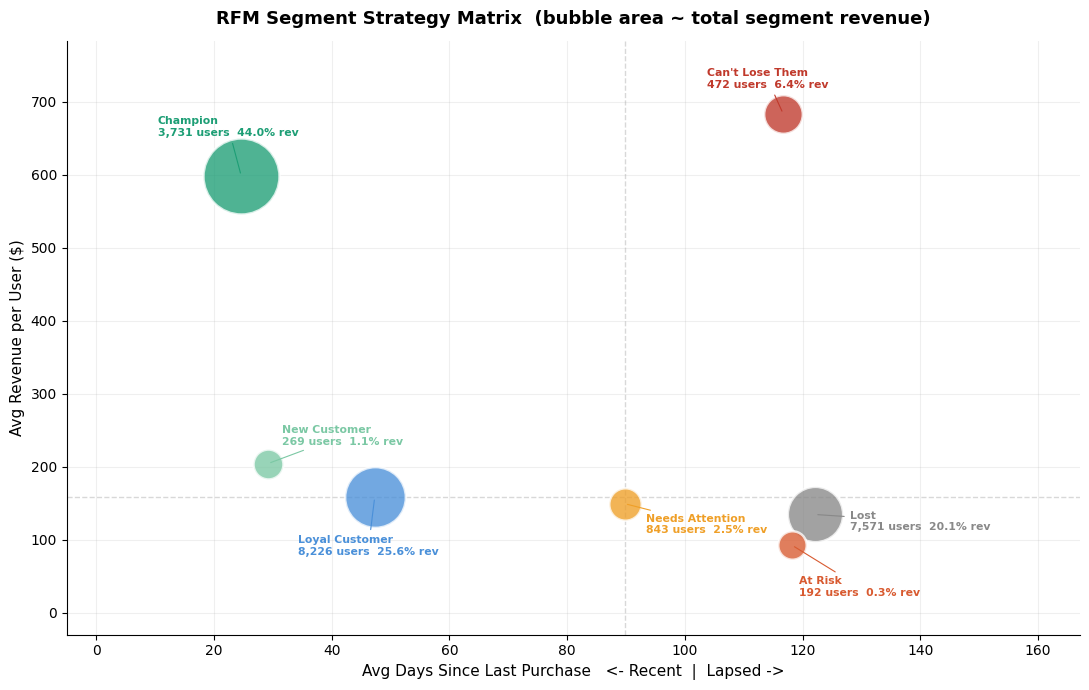

Saved: charts/RFM_Segment_Strategy_Matrix.png


In [5]:
# Chart 05 - RFM Segment Strategy Matrix
seg_plot_05 = seg_summary.copy().reset_index(drop=True)
max_rev = seg_plot_05['total_revenue'].max()
sizes_05 = 400 + 2600 * (seg_plot_05['total_revenue'] / max_rev)

# Per-segment label offsets to avoid overlap
_OFFSETS = {
    'Champion':        (-60, 35),
    'Loyal Customer':  (-55, -35),
    "Can't Lose Them": (-55, 25),
    'New Customer':    (10, 20),
    'Needs Attention': (15, -15),
    'At Risk':         (5, -30),
    'Lost':            (25, -5),
}

fig, ax = plt.subplots(figsize=(11, 7))

for idx, row in seg_plot_05.iterrows():
    seg = row['rfm_segment']
    color = SEGMENT_COLORS.get(seg, GRAY)
    s = sizes_05[idx]

    ax.scatter(
        row['avg_recency_days'],
        row['avg_revenue'],
        s=s,
        color=color,
        alpha=0.78,
        edgecolors='white',
        linewidth=1.8,
        zorder=3
    )

    stats = f"{row['user_count']:,} users  {row['pct_of_revenue']:.1f}% rev"

    xo, yo = _OFFSETS.get(seg, (15, 15))

    ax.annotate(
        seg + '\n' + stats,
        xy=(row['avg_recency_days'], row['avg_revenue']),
        xytext=(xo, yo),
        textcoords='offset points',
        fontsize=7.8,
        color=color,
        fontweight='bold',
        ha='left',
        va='center',
        arrowprops=dict(
            arrowstyle='-',
            color=color,
            lw=0.8
        ),
        zorder=5
    )

med_rec = seg_plot_05['avg_recency_days'].median()
med_rev = seg_plot_05['avg_revenue'].median()
ax.axvline(med_rec, color=GRAY, linestyle='--', linewidth=1, alpha=0.45)
ax.axhline(med_rev, color=GRAY, linestyle='--', linewidth=1, alpha=0.45)

ax.set_xlabel('Avg Days Since Last Purchase   <- Recent  |  Lapsed ->', fontsize=11)
ax.set_ylabel('Avg Revenue per User ($)', fontsize=11)
ax.set_title('RFM Segment Strategy Matrix  (bubble area ~ total segment revenue)',
             fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.2)
ax.set_xlim(-5, seg_plot_05['avg_recency_days'].max() + 45)
ax.set_ylim(-30, seg_plot_05['avg_revenue'].max() + 100)

plt.tight_layout()
plt.savefig('charts/RFM_Segment_Strategy_Matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/RFM_Segment_Strategy_Matrix.png')

## 3.4 Segment Revenue Table

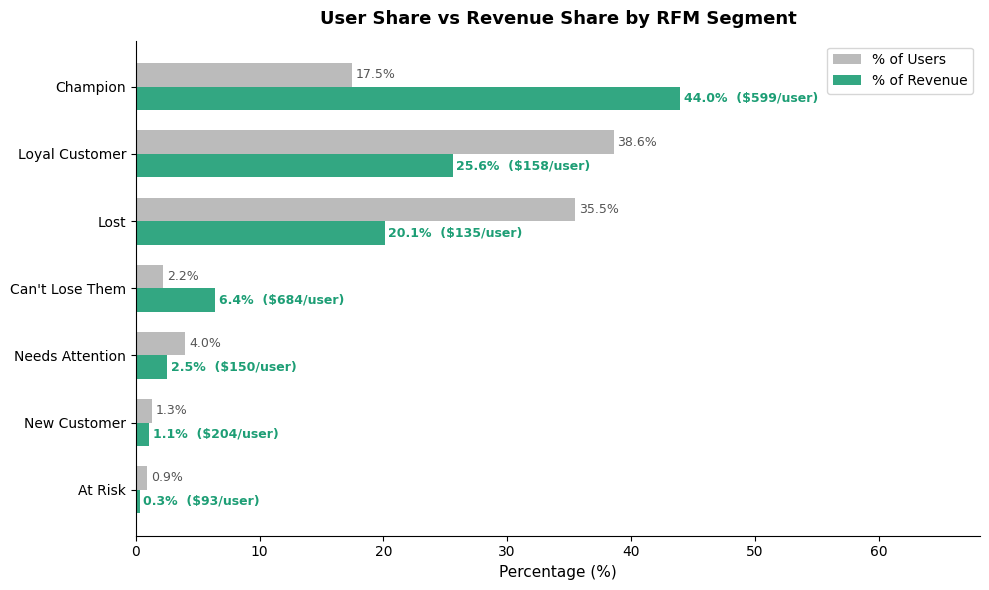

Saved: charts/User_Share_vs_Revenue_Share.png


In [6]:
# Grouped horizontal bar: % users vs % revenue per segment
seg_plot = seg_summary.sort_values('pct_of_revenue', ascending=True)

y = np.arange(len(seg_plot))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.barh(y + height/2, seg_plot['pct_of_users'],   height, color=GRAY,  alpha=0.8, label='% of Users')
bars2 = ax.barh(y - height/2, seg_plot['pct_of_revenue'], height, color=TEAL,  alpha=0.9, label='% of Revenue')

for bar in bars1:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9, color='#555')
for bar, row in zip(bars2, seg_plot.itertuples()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%  (${row.avg_revenue:.0f}/user)',
            va='center', fontsize=9, color=TEAL, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(seg_plot['rfm_segment'], fontsize=10)
ax.set_xlabel('Percentage (%)', fontsize=11)
ax.set_title('User Share vs Revenue Share by RFM Segment', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
# Widen xlim to fit the $/user annotation text
ax.set_xlim(0, max(seg_plot['pct_of_users'].max(), seg_plot['pct_of_revenue'].max()) * 1.55)

plt.tight_layout()
plt.savefig('charts/User_Share_vs_Revenue_Share.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/User_Share_vs_Revenue_Share.png")

## 3.5 Generate loyalty_offers.csv

In [7]:
np.random.seed(42)

target_segs = ['At Risk', "Can't Lose Them", 'Lost']
target_users = ph[ph['rfm_segment'].isin(target_segs)][['user_id', 'rfm_segment']].copy()
print(f"Target users for loyalty campaign: {len(target_users):,}")

# Equal split across 3 offer types
offer_types = ['email_discount', 'push_cashback', 'control']
target_users['offer_type'] = np.random.choice(offer_types, size=len(target_users), replace=True)

# Discount pct per offer
target_users['discount_pct'] = target_users['offer_type'].map({
    'email_discount': 10,
    'push_cashback':  5,
    'control':        0
})

# Simulate conversion
conv_rates = {'email_discount': 0.18, 'push_cashback': 0.12, 'control': 0.04}
target_users['converted'] = target_users['offer_type'].apply(
    lambda o: np.random.random() < conv_rates[o]
)

# Simulate order values for converted users
order_params = {
    'email_discount': (185, 45),
    'push_cashback':  (165, 40),
    'control':        (175, 42),
}

def simulate_order_value(row):
    if not row['converted']:
        return None
    loc, scale = order_params[row['offer_type']]
    return max(20.0, np.random.normal(loc, scale))

target_users['order_value'] = target_users.apply(simulate_order_value, axis=1)

# Offer date = max_date + random 1–30 days
target_users['offer_date'] = max_date + pd.to_timedelta(
    np.random.randint(1, 31, size=len(target_users)), unit='D'
)

loyalty_offers = target_users[['user_id','rfm_segment','offer_type','offer_date',
                                'discount_pct','converted','order_value']].copy()

out_path = '../data/processed/loyalty_offers.csv'
loyalty_offers.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Rows: {len(loyalty_offers):,}")
print(loyalty_offers.groupby('offer_type')['converted'].agg(['sum','count','mean']).round(3))

Target users for loyalty campaign: 8,235
Saved: ../data/processed/loyalty_offers.csv
Rows: 8,235
                sum  count   mean
offer_type                       
control         108   2713  0.040
email_discount  495   2782  0.178
push_cashback   344   2740  0.126


## 3.6 Loyalty ROI Chart

In [8]:
# ROI analysis
COST_PER_USER = 0.50

roi_summary = loyalty_offers.groupby('offer_type').agg(
    users_targeted=('user_id', 'count'),
    conversions=('converted', 'sum'),
    total_revenue=('order_value', 'sum')
).reset_index()

roi_summary['conversion_rate_pct'] = (100 * roi_summary['conversions'] / roi_summary['users_targeted']).round(1)
roi_summary['avg_order_value'] = (loyalty_offers[loyalty_offers['converted']]
                                   .groupby('offer_type')['order_value'].mean().round(2).values)
roi_summary['total_cost'] = roi_summary['users_targeted'] * COST_PER_USER
roi_summary['roi_ratio']  = (roi_summary['total_revenue'] / roi_summary['total_cost']).round(2)
roi_summary['total_revenue'] = roi_summary['total_revenue'].round(2)

print(roi_summary.to_string(index=False))

    offer_type  users_targeted  conversions  total_revenue  conversion_rate_pct  avg_order_value  total_cost  roi_ratio
       control            2713          108       18588.84                  4.0           172.12      1356.5       13.7
email_discount            2782          495       91527.13                 17.8           184.90      1391.0       65.8
 push_cashback            2740          344       56584.96                 12.6           164.49      1370.0       41.3


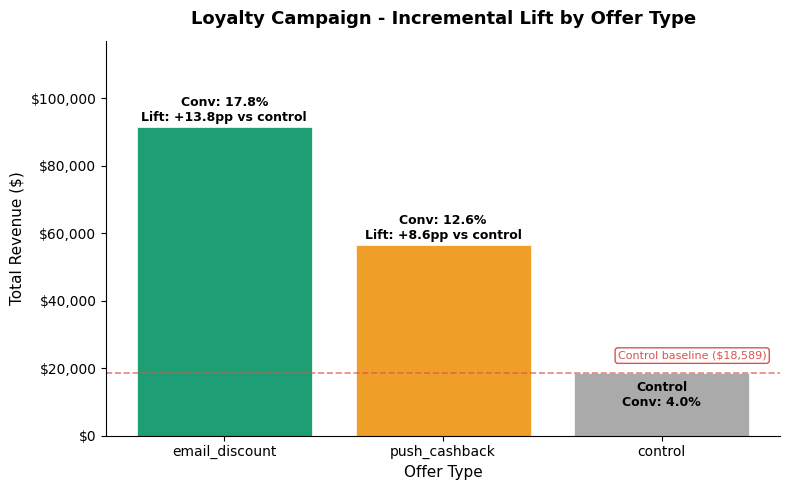

Saved: charts/Loyalty_Campaign_Incremental_Lift.png


In [9]:
offer_colors = {'email_discount': TEAL, 'push_cashback': AMBER, 'control': GRAY}
roi_plot = roi_summary.sort_values('total_revenue', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(roi_plot['offer_type'], roi_plot['total_revenue'],
              color=[offer_colors[o] for o in roi_plot['offer_type']],
              edgecolor='white', linewidth=0.5)

ctrl_conv = roi_summary.loc[roi_summary['offer_type'] == 'control', 'conversion_rate_pct'].iloc[0]
ctrl_revenue = roi_summary.loc[roi_summary['offer_type'] == 'control', 'total_revenue'].iloc[0]

for bar, (_, row) in zip(bars, roi_plot.iterrows()):

    if row['offer_type'] == 'control':

        label = f"Control\nConv: {row['conversion_rate_pct']:.1f}%"

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() * 0.65,
            label,
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

    else:
        lift_pp = row['conversion_rate_pct'] - ctrl_conv

        label = (
            f"Conv: {row['conversion_rate_pct']:.1f}%\n"
            f"Lift: +{lift_pp:.1f}pp vs control"
        )

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + roi_plot['total_revenue'].max()*0.01,
            label,
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

# Reference dashed line at control revenue level
ax.axhline(ctrl_revenue, color='#D9534F', linestyle='--', linewidth=1.2, alpha=0.7, zorder=1)
ax.text(0.98, ctrl_revenue + roi_plot['total_revenue'].max() * 0.04,
        f'Control baseline (${ctrl_revenue:,.0f})',
        transform=ax.get_yaxis_transform(),
        ha='right', va='bottom', fontsize=8, color='#D9534F',
         bbox=dict(
        facecolor='white',
        edgecolor='#D9534F',
        boxstyle='round,pad=0.25'
    ))

ax.set_title('Loyalty Campaign - Incremental Lift by Offer Type', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Offer Type', fontsize=11)
ax.set_ylabel('Total Revenue ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, roi_plot['total_revenue'].max() * 1.28)

plt.tight_layout()
plt.savefig('charts/Loyalty_Campaign_Incremental_Lift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/Loyalty_Campaign_Incremental_Lift.png")

## 3.7 Pareto Validation

In [10]:
user_revenue = ph[['user_id', 'monetary']].sort_values('monetary', ascending=False).reset_index(drop=True)
user_revenue['cumulative_revenue'] = user_revenue['monetary'].cumsum()
user_revenue['pct_users']   = 100 * (user_revenue.index + 1) / len(user_revenue)
user_revenue['pct_revenue'] = 100 * user_revenue['cumulative_revenue'] / user_revenue['monetary'].sum()

# Find the user % where 80% revenue is reached
idx_80 = user_revenue[user_revenue['pct_revenue'] >= 80].index[0]
pct_users_for_80 = user_revenue.loc[idx_80, 'pct_users']
print(f"Top {pct_users_for_80:.1f}% of users drive 80% of revenue")

# Gini coefficient (Lorenz curve, ascending sort)
rev_asc = np.sort(ph['monetary'].values)
lorenz_y = np.cumsum(rev_asc) / rev_asc.sum()
lorenz_x = np.linspace(0, 1, len(rev_asc))
gini = 1 - 2 * np.trapezoid(lorenz_y, lorenz_x)
print(f"Gini coefficient: {gini:.3f}")

# Second annotation: top 10% threshold
idx_10 = user_revenue[user_revenue['pct_users'] >= 10].index[0]
pct_rev_for_top10 = user_revenue.loc[idx_10, 'pct_revenue']
print(f"Top 10% of users -> {pct_rev_for_top10:.1f}% of revenue")

Top 30.6% of users drive 80% of revenue
Gini coefficient: 0.647
Top 10% of users -> 48.1% of revenue


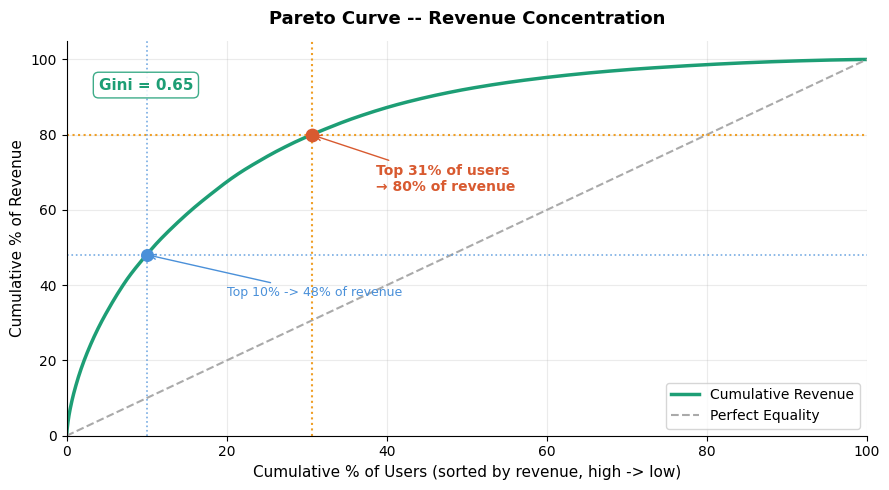

Saved: charts/Revenue_Concentration.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(user_revenue['pct_users'], user_revenue['pct_revenue'],
        color=TEAL, linewidth=2.5, label='Cumulative Revenue')

# Perfect equality line
ax.plot([0, 100], [0, 100], color=GRAY, linestyle='--', linewidth=1.5, label='Perfect Equality')

# 80% annotation
ax.axhline(80, color=AMBER, linestyle=':', linewidth=1.5)
ax.axvline(pct_users_for_80, color=AMBER, linestyle=':', linewidth=1.5)
ax.scatter([pct_users_for_80], [80], color=CORAL, zorder=5, s=80)
ax.annotate(
    f'Top {pct_users_for_80:.0f}% of users\n→ 80% of revenue',
    xy=(pct_users_for_80, 80),
    xytext=(pct_users_for_80 + 8, 65),
    fontsize=10, color=CORAL, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=CORAL)
)

# Second crosshair: top 10%
ax.axvline(10, color=BLUE, linestyle=':', linewidth=1.2, alpha=0.75)
ax.axhline(pct_rev_for_top10, color=BLUE, linestyle=':', linewidth=1.2, alpha=0.75)
ax.scatter([10], [pct_rev_for_top10], color=BLUE, zorder=5, s=70)
ax.annotate(
    f'Top 10% -> {pct_rev_for_top10:.0f}% of revenue',
    xy=(10, pct_rev_for_top10),
    xytext=(20, pct_rev_for_top10 - 11),
    fontsize=9, color=BLUE,
    arrowprops=dict(arrowstyle='->', color=BLUE)
)

# Gini coefficient text box
ax.text(4, 92, f'Gini = {gini:.2f}',
        fontsize=11, fontweight='bold', color=TEAL,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor=TEAL, alpha=0.85))

ax.set_xlabel('Cumulative % of Users (sorted by revenue, high -> low)', fontsize=11)
ax.set_ylabel('Cumulative % of Revenue', fontsize=11)
ax.set_title('Pareto Curve -- Revenue Concentration', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.25)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('charts/Revenue_Concentration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/Revenue_Concentration.png")

## Key Numbers

Fill these into the executive memo from the outputs above:

| Metric | Value |
|--------|-------|
| Pareto threshold | Top X% of users → 80% of revenue |
| At Risk users | See `seg_summary` |
| At Risk total historical spend | See `seg_summary` |
| Email conversion vs control | 18% vs 4% |
| Email ROI vs push ROI | See `roi_summary` |

## 3.8 Q4 Loyalty ROI — SQL Query Execution

In [12]:
import duckdb
from pathlib import Path

sql_path = Path('../sql/queries/q4_loyalty_roi.sql')
csv_path = Path('../data/processed/loyalty_offers.csv')

query = sql_path.read_text()

# Replace bare table name with a DuckDB read_csv call
query_duck = query.replace(
    'FROM loyalty_offers',
    f"FROM read_csv_auto('{csv_path.as_posix()}')"
)

q4_result = duckdb.query(query_duck).df()
print(q4_result.to_string(index=False))
q4_result

    offer_type     rfm_segment  users_targeted  conversions  conversion_rate_pct  avg_order_value  total_revenue  roi_ratio
email_discount         At Risk              63         12.0                 19.0           192.03        2304.41      73.16
       control         At Risk              69          4.0                  5.8           192.93         771.73      22.37
 push_cashback         At Risk              60          3.0                  5.0           135.24         405.71      13.52
 push_cashback Can't Lose Them             159         26.0                 16.4           168.75        4387.48      55.19
email_discount Can't Lose Them             162         18.0                 11.1           191.20        3441.52      42.49
       control Can't Lose Them             151          5.0                  3.3           146.06         730.28       9.67
email_discount            Lost            2557        465.0                 18.2           184.48       85781.20      67.10
 push_ca

,offer_type,rfm_segment,users_targeted,conversions,conversion_rate_pct,avg_order_value,total_revenue,roi_ratio
0,email_discount,At Risk,63,12.0,19.0,192.03,2304.41,73.16
1,control,At Risk,69,4.0,5.8,192.93,771.73,22.37
2,push_cashback,At Risk,60,3.0,5.0,135.24,405.71,13.52
3,push_cashback,Can't Lose Them,159,26.0,16.4,168.75,4387.48,55.19
4,email_discount,Can't Lose Them,162,18.0,11.1,191.20,3441.52,42.49
5,control,Can't Lose Them,151,5.0,3.3,146.06,730.28,9.67
6,email_discount,Lost,2557,465.0,18.2,184.48,85781.20,67.10
7,push_cashback,Lost,2521,315.0,12.5,164.42,51791.77,41.09
8,control,Lost,2493,99.0,4.0,172.59,17086.83,13.71
